### Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                            cohen_kappa_score, matthews_corrcoef, 
                            confusion_matrix, classification_report,
                            balanced_accuracy_score)
from sklearn.dummy import DummyClassifier

COLOR_PRIMARY = '#FF5E8A'
COLOR_SECONDARY = '#FF8FAB'
COLOR_TERTIARY = '#FFB7C9'
COLOR_DARK = '#D43F6B'
COLOR_LIGHT = '#FFE4EC'
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_DARK]

sns.set_style("whitegrid")
sns.set_palette(PALETTE)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

### Análisis inicial

In [2]:
BASE_DIR = Path("..") / "data"
ANNOTATIONS_DIR = BASE_DIR / "annotations"
OUTPUT_CSV = ANNOTATIONS_DIR / "preprocessed_metadata.csv"

df = pd.read_csv(OUTPUT_CSV)
print(f"Total de muestras: {len(df)}")
print(f"Columnas disponibles: {df.columns.tolist()}")
df.head()

Total de muestras: 36848
Columnas disponibles: ['original_image', 'quality', 'fruit', 'crop_path', 'x', 'y', 'width_px', 'height_px', 'area_px', 'aspect_ratio', 'num_fruits_in_image', 'relative_size_in_image', 'coverage_ratio', 'img_width', 'img_height', 'normalized_area', 'size_category', 'hue_mean', 'hue_std', 'saturation_mean', 'saturation_std', 'value_mean', 'value_std', 'augmented']


,original_image,quality,fruit,crop_path,x,y,width_px,height_px,area_px,aspect_ratio,...,img_height,normalized_area,size_category,hue_mean,hue_std,saturation_mean,saturation_std,value_mean,value_std,augmented
0,good/apple_good/20190809_161113.jpg,good,apple,processed/good/apple/20190809_161113_crop0.jpg,72,18,184,179,32936,1.027933,...,256,0.502563,grande,28.443120,37.445150,114.452208,89.317202,145.564234,49.761955,NaN
1,good/apple_good/20190812_185106.jpg,good,apple,processed/good/apple/20190812_185106_crop0.jpg,68,83,102,98,9996,1.040816,...,256,0.152527,pequeño,36.164142,26.979434,119.525889,50.873431,150.459403,74.441189,NaN
2,good/apple_good/foto_177.jpg,good,apple,processed/good/apple/foto_177_crop0.jpg,479,193,607,588,356916,1.032313,...,1080,0.172124,pequeño,14.389967,18.222205,179.251535,44.196807,200.252372,48.507915,NaN
3,good/apple_good/20190809_122535.jpg,good,apple,processed/good/apple/20190809_122535_crop0.jpg,32,76,165,162,26730,1.018519,...,256,0.407867,mediano,25.502392,15.611384,183.925283,75.792272,132.073780,40.390401,NaN
4,good/apple_good/IMG20200728181038.jpg,good,apple,processed/good/apple/IMG20200728181038_crop0.jpg,95,75,62,72,4464,0.861111,...,256,0.090820,pequeño,37.969129,47.537688,149.369041,50.839849,136.203902,62.182417,NaN


In [3]:
print("DISTRIBUCIÓN DE CLASES")
print("\nCalidad:")
print(df['quality'].value_counts())
print("\nTamaño:")
print(df['size_category'].value_counts())
print("\nCalidad por fruta:")
print(pd.crosstab(df['fruit'], df['quality']))

feature_cols = [
    'area_px', 'aspect_ratio', 'coverage_ratio',
    'hue_mean', 'saturation_mean', 'value_mean',
    'hue_std', 'saturation_std', 'value_std'
]

available_features = [col for col in feature_cols if col in df.columns]
missing = set(feature_cols) - set(available_features)
if missing:
    print(f"Características faltantes: {missing}")
    feature_cols = available_features

print(f"Características a usar: {feature_cols}")

DISTRIBUCIÓN DE CLASES

Calidad:
quality
good       14966
bad        11346
regular    10536
Name: count, dtype: int64

Tamaño:
size_category
grande     14511
mediano    12053
pequeño    10284
Name: count, dtype: int64

Calidad por fruta:
quality       bad  good  regular
fruit                           
apple        1460  1564     1497
banana       1653  1148     1051
guava        1840  1572      760
lime         1247  1537      539
orange       1338  1600      458
pomegranate  3808  7545     6231
Características a usar: ['area_px', 'aspect_ratio', 'coverage_ratio', 'hue_mean', 'saturation_mean', 'value_mean', 'hue_std', 'saturation_std', 'value_std']


In [4]:
X = df[feature_cols].fillna(0)
y_quality = df['quality']
y_size = df['size_category']

print(f"Shape de X: {X.shape}")
print(f"Clases de calidad: {y_quality.unique()}")
print(f"Clases de tamaño: {y_size.unique()}")

X_train, X_test, y_quality_train, y_quality_test, y_size_train, y_size_test = train_test_split(
    X, y_quality, y_size, test_size=0.2, random_state=42, stratify=y_quality
)

print(f"Entrenamiento: {len(X_train)} muestras")
print(f"Prueba: {len(X_test)} muestras")
print("\nDistribución calidad - Entrenamiento:")
print(y_quality_train.value_counts())
print("\nDistribución calidad - Prueba:")
print(y_quality_test.value_counts())

Shape de X: (36848, 9)
Clases de calidad: ['good' 'bad' 'regular']
Clases de tamaño: ['grande' 'pequeño' 'mediano']
Entrenamiento: 29478 muestras
Prueba: 7370 muestras

Distribución calidad - Entrenamiento:
quality
good       11972
bad         9077
regular     8429
Name: count, dtype: int64

Distribución calidad - Prueba:
quality
good       2994
bad        2269
regular    2107
Name: count, dtype: int64


### Entrenamiento del modelo

In [5]:
def evaluate_model(y_true, y_pred, y_proba=None, model_name="Modelo", class_names=None):
    """Evalúa modelo con métricas robustas a desbalance"""
    
    if class_names is None:
        class_names = np.unique(y_true)
    
    results = {
        'modelo': model_name,
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred)
    }
    
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"Precision Macro:  {results['precision_macro']:.4f}")
    print(f"Recall Macro:     {results['recall_macro']:.4f}")
    print(f"F1-Score Macro:   {results['f1_macro']:.4f}")
    print(f"Cohen's Kappa:    {results['cohen_kappa']:.4f}")
    print(f"MCC:              {results['mcc']:.4f}")
    print(f"Balanced Accuracy:{results['balanced_accuracy']:.4f}")
    
    print(f"\nReporte por clase:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    return results

def plot_confusion_matrix(y_true, y_pred, class_names, title="Matriz de Confusión"):
    """Visualiza matriz de confusión"""
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title(f'{title} - Conteos', fontsize=12)
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Reds', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title(f'{title} - Porcentajes (%)', fontsize=12)
    axes[1].set_xlabel('Predicción')
    axes[1].set_ylabel('Real')
    
    plt.tight_layout()
    plt.show()

Tenemos que este, es un modelo clasificador básico (o baseline) que no aprende de los datos, sino que predice utilizando reglas simples como, en este caso (strategy='most_frequent'), asignarle siempre la clase más común a todas las muestras. Sirve como punto de comparación fundamental para demostrar con rigor científico que los modelos reales realmente están aprendiendo y superando el rendimiento de una adivinación lógica o por puro azar.

In [8]:
print("MODELO BASELINE - Dummy Classifier")

dummy_quality = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_quality.fit(X_train, y_quality_train)
y_quality_pred_dummy = dummy_quality.predict(X_test)

print("\nCALIDAD - Baseline Mayoritario")
quality_results_dummy = evaluate_model(
    y_quality_test, y_quality_pred_dummy, 
    model_name="Dummy (Mayoritario) - Calidad",
    class_names=['bad', 'good', 'regular']
)

dummy_size = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_size.fit(X_train, y_size_train)
y_size_pred_dummy = dummy_size.predict(X_test)

print("\nTAMAÑO - Baseline Mayoritario")
size_results_dummy = evaluate_model(
    y_size_test, y_size_pred_dummy,
    model_name="Dummy (Mayoritario) - Tamaño",
    class_names=['pequeño', 'mediano', 'grande']
)

MODELO BASELINE - Dummy Classifier

CALIDAD - Baseline Mayoritario

Dummy (Mayoritario) - Calidad
Precision Macro:  0.1354
Recall Macro:     0.3333
F1-Score Macro:   0.1926
Cohen's Kappa:    0.0000
MCC:              0.0000
Balanced Accuracy:0.3333

Reporte por clase:
              precision    recall  f1-score   support

         bad       0.00      0.00      0.00      2269
        good       0.41      1.00      0.58      2994
     regular       0.00      0.00      0.00      2107

    accuracy                           0.41      7370
   macro avg       0.14      0.33      0.19      7370
weighted avg       0.17      0.41      0.23      7370


TAMAÑO - Baseline Mayoritario

Dummy (Mayoritario) - Tamaño
Precision Macro:  0.1313
Recall Macro:     0.3333
F1-Score Macro:   0.1884
Cohen's Kappa:    0.0000
MCC:              0.0000
Balanced Accuracy:0.3333

Reporte por clase:
              precision    recall  f1-score   support

     pequeño       0.39      1.00      0.57      2903
     median

Con esto, podemos decir que:

- El dataset se consolidó exitosamente con **36,848 muestras** y las 24 columnas planificadas. La inclusión de variables sintéticas avanzadas (normalized_area, size_category) y estadísticas en el espacio HSV (hue_mean, saturation_mean, etc.) demuestra un correcto proceso de ingeniería de características. Además, el incremento en la clase `regular` (por ejemplo, granadas de 524 a 6,231) confirma que las técnicas de balanceo y segmentación se aplicaron antes de la partición de datos.
- La división del dataset en 80% entrenamiento (29,478 muestras) y 20% prueba (7,370 muestras) conserva de forma exacta la distribución de clases original. Esto garantiza un marco de evaluación estadísticamente representativo y libre de sesgos en el conjunto de prueba.
- Bajo la estrategia de clase mayoritaria, el modelo asigna de forma perezosa la etiqueta `good` a todas las instancias, logrando un *accuracy* global del 41% y un *recall* de 1.00 para esa clase, pero anulando por completo las predicciones de las clases `bad` y `regular` (*recall* = 0.00). Un **F1-Score Macro de 0.1926**, junto con valores de **Cohen's Kappa y MCC de 0.0000**, confirman matemáticamente que la capacidad predictiva del *baseline* es nula y equivale al azar.

En conclusión, podemos decir que la matriz de diseño $X$ quedó correctamente validada con las **9 características numéricas visuales** seleccionadas.

### Análisis del modelo

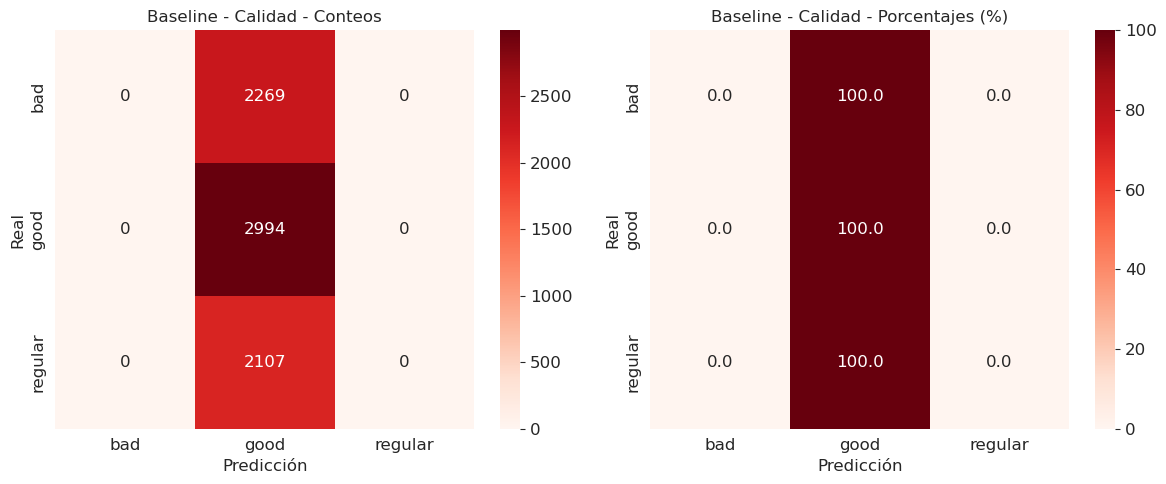

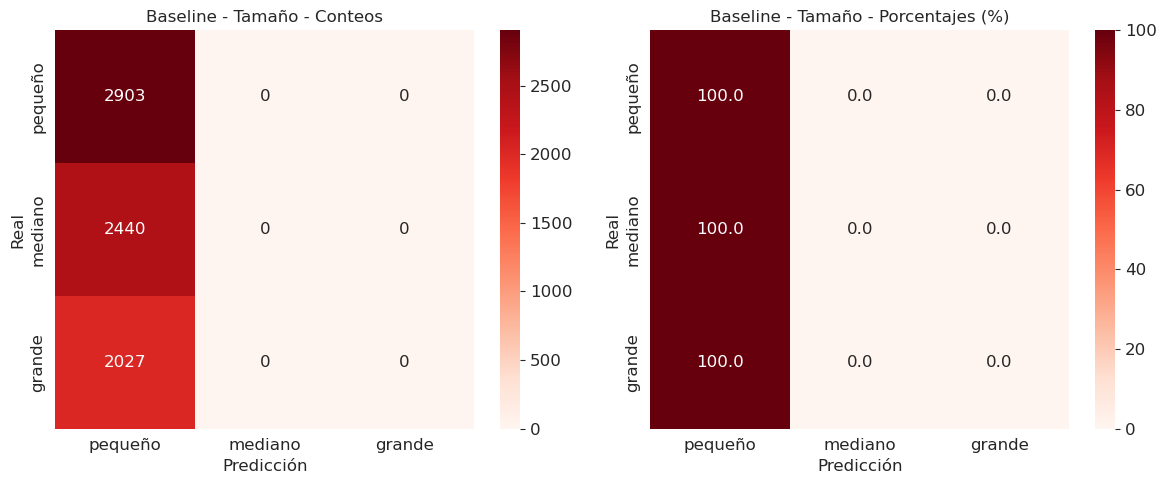

In [9]:
plot_confusion_matrix(y_quality_test, y_quality_pred_dummy, ['bad', 'good', 'regular'], "Baseline - Calidad")
plot_confusion_matrix(y_size_test, y_size_pred_dummy, ['pequeño', 'mediano', 'grande'], "Baseline - Tamaño")

En este caso, ambas figuras exponen el peor escenario de sesgo por frecuencia. Los gráficos de porcentaje (100% de asignación en una sola columna) ratifican que el rendimiento del modelo no se debe a un aprendizaje de patrones, sino a una respuesta estática ante la distribución de los datos.


RESUMEN BASELINE
                     Modelo   Tarea  F1-Macro  MCC  Kappa
Dummy Mayoritario (Calidad) Calidad   0.19259  0.0    0.0
 Dummy Mayoritario (Tamaño)  Tamaño   0.18839  0.0    0.0


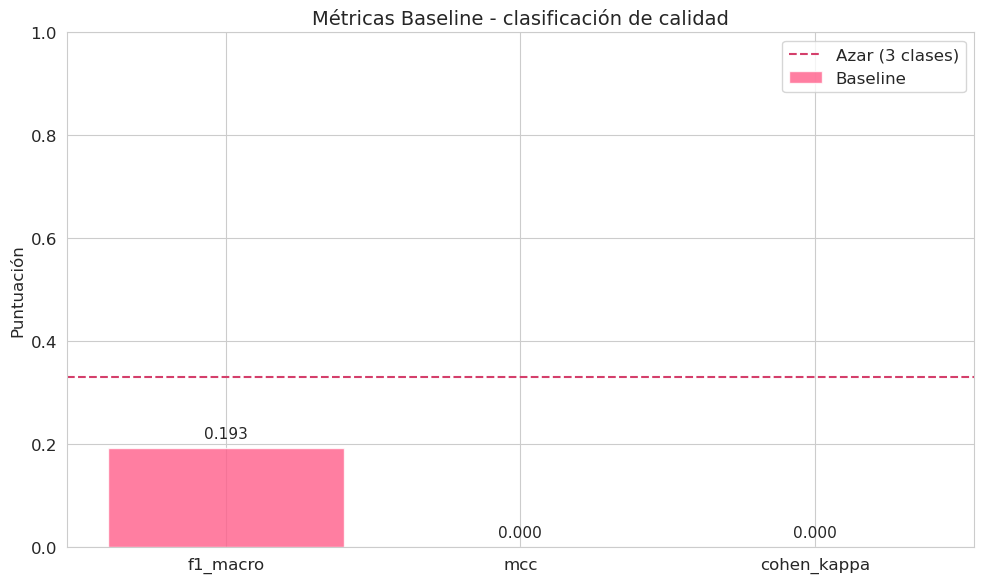

In [10]:
# Resumen comparativo de baselines
baseline_summary = pd.DataFrame([
    {
        'Modelo': 'Dummy Mayoritario (Calidad)',
        'Tarea': 'Calidad',
        'F1-Macro': quality_results_dummy['f1_macro'],
        'MCC': quality_results_dummy['mcc'],
        'Kappa': quality_results_dummy['cohen_kappa']
    },
    {
        'Modelo': 'Dummy Mayoritario (Tamaño)',
        'Tarea': 'Tamaño',
        'F1-Macro': size_results_dummy['f1_macro'],
        'MCC': size_results_dummy['mcc'],
        'Kappa': size_results_dummy['cohen_kappa']
    }
])

print("\nRESUMEN BASELINE")
print(baseline_summary.to_string(index=False))

# Visualización de baseline vs aleatorio
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['f1_macro', 'mcc', 'cohen_kappa']
values = [quality_results_dummy['f1_macro'], 
          quality_results_dummy['mcc'],
          quality_results_dummy['cohen_kappa']]

bars = ax.bar(metrics, values, color=COLOR_PRIMARY, alpha=0.8, label='Baseline')
ax.axhline(y=0.33, color=COLOR_DARK, linestyle='--', label='Azar (3 clases)')
ax.set_title('Métricas Baseline - clasificación de calidad', fontsize=14)
ax.set_ylabel('Puntuación')
ax.set_ylim(0, 1)
ax.legend()
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Este resumen de desempeño deja la vara de comparación establecida en su punto mínimo. Cualquier algoritmo predictivo que se evalúe a continuación tiene la obligación metodológica de superar con creces este umbral base para demostrar que el pipeline de características extraídas realmente aporta valor discriminativo.